# Week 2 · Lab — Simulated Annealing for the TSP and MAX-3SAT

**Goals**
- Build a fast SA for the Euclidean TSP with **2-opt** and **or-opt** moves, **$O(1)$ delta evaluation** and
  neighbour lists; validate the deltas against full recomputation and the tours against **Held–Karp** optima.
- Run a schedule-tuning study ($T_0$ via target acceptance, $T_{\text{end}}$) at a fixed evaluation budget, and
  compare tour lengths for $n = 50$–$200$ with the **Beardwood–Halton–Hammersley** asymptotics.
- Build SA for **MAX-3SAT near the satisfiability threshold** ($m/n\approx4.26$) with incremental clause
  bookkeeping, validate against exhaustive search, and compare focused (WalkSAT-style) and unfocused
  variants at equal budgets.
- Use SA for a small, exactly solvable **hyperparameter / feature-subset search** problem.

**Prerequisites:** Notebooks 1–3 of this week; Week 1 (TSP, neighbourhoods, MAX-SAT).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
import math
from scipy.optimize import brentq
from scipy.stats import wilcoxon, binomtest
from utils import (random_euclidean_tsp, tour_length, held_karp, bhh_constant_estimate,
                   random_max3sat, count_satisfied, PALETTE)

## Part A — Euclidean TSP

### A.1 Moves with $O(1)$ deltas

A tour is a cyclic permutation $t$; `pos[c]` is the position of city $c$.

* **2-opt** (Croes 1958): remove edges $(a,b)=(t_i,t_{i+1})$ and $(c,d)=(t_j,t_{j+1})$, reconnect as $(a,c),(b,d)$ by
  reversing the path between them:
  $\Delta = D_{ac} + D_{bd} - D_{ab} - D_{cd}$.
* **or-opt** (Or 1976): move a segment $s_1\dots s_L$ ($L\le 3$) with predecessor $p$ and successor $x$ between
  adjacent cities $c, e$, possibly reversed:
  $\Delta = D_{px} - D_{ps_1} - D_{s_Lx} + \min(D_{cs_1}+D_{s_Le},\ D_{cs_L}+D_{s_1e}) - D_{ce}$.

Both deltas cost $O(1)$; applying an accepted move costs $O(n)$ in the worst case, but acceptances become rare as
$T$ falls. **Neighbour lists** (the $k=10$ nearest cities; Johnson & McGeoch 1997) restrict $c$ to cities close to
$a$ (or $s_1$) — almost all improving moves are of this form. This makes the proposal asymmetric, which is harmless
for optimisation (we are not sampling a Boltzmann law) but should be remembered.

One **evaluation** = one computed delta (proposals rejected before computing a delta — degenerate moves — are also
counted, to be conservative).

In [2]:
def neighbour_lists(D, k):
    return np.argsort(D, axis=1)[:, 1:k + 1].tolist()


def nearest_neighbour_tour(D, start=0):
    n = len(D); left = set(range(n)); t = [start]; left.remove(start)
    while left:
        a = t[-1]; b = min(left, key=lambda j: D[a, j]); t.append(b); left.remove(b)
    return t


def two_opt_delta(t, pos, Dl, i, c):
    n = len(t); a, b = t[i], t[(i + 1) % n]
    j = pos[c]; d = t[(j + 1) % n]
    if c == b or d == a:
        return None
    return Dl[a][c] + Dl[b][d] - Dl[a][b] - Dl[c][d], j


def apply_two_opt(t, pos, i, j):
    lo, hi = (i + 1, j) if i < j else (j + 1, i)
    seg = t[lo:hi + 1]; seg.reverse(); t[lo:hi + 1] = seg
    for q in range(lo, hi + 1):
        pos[t[q]] = q


def or_opt_delta(t, pos, Dl, i, L, c):
    n = len(t)
    if i + L > n:
        return None
    s1, sL, p, x = t[i], t[i + L - 1], t[i - 1], t[(i + L) % n]
    jc = pos[c]
    if i <= jc < i + L or c == p:
        return None
    e = t[(jc + 1) % n]
    if i <= pos[e] < i + L:
        return None
    fwd, rev = Dl[c][s1] + Dl[sL][e], Dl[c][sL] + Dl[s1][e]
    return Dl[p][x] - Dl[p][s1] - Dl[sL][x] + min(fwd, rev) - Dl[c][e], rev < fwd


def apply_or_opt(t, i, L, c, reverse):
    seg = t[i:i + L]
    if reverse:
        seg.reverse()
    rest = t[:i] + t[i + L:]
    ic = rest.index(c)
    return rest[:ic + 1] + seg + rest[ic + 1:]


# --- validation: every delta equals the change of the full tour length (utils.tour_length)
_, Dv = random_euclidean_tsp(40, np.random.default_rng(1))
Dl = Dv.tolist(); NB = neighbour_lists(Dv, 10); vr = np.random.default_rng(2)
err2, err_or, n2, nor = 0.0, 0.0, 0, 0
t = list(vr.permutation(40)); pos = [0] * 40
for q, c in enumerate(t): pos[c] = q
while n2 < 300 or nor < 300:
    i = int(vr.integers(40)); c = NB[t[i]][int(vr.integers(10))]
    before = tour_length(t, Dv)
    if vr.random() < 0.5:
        r = two_opt_delta(t, pos, Dl, i, c)
        if r is None: continue
        apply_two_opt(t, pos, i, r[1]); err2 = max(err2, abs(tour_length(t, Dv) - before - r[0])); n2 += 1
    else:
        L = int(vr.integers(1, 4)); c = NB[t[i]][int(vr.integers(10))]
        r = or_opt_delta(t, pos, Dl, i, L, c)
        if r is None: continue
        t = apply_or_opt(t, i, L, c, r[1])
        for q, cc in enumerate(t): pos[cc] = q
        err_or = max(err_or, abs(tour_length(t, Dv) - before - r[0])); nor += 1
    check_ok = sorted(t) == list(range(40))
    if not check_ok: break
check_true(check_ok, "tour remains a permutation after every applied move")
check_close(err2, 0.0, f"2-opt O(1) delta = full recomputation (max error over {n2} random moves)", atol=1e-9)
check_close(err_or, 0.0, f"or-opt O(1) delta = full recomputation (max error over {nor} random moves)", atol=1e-9)

[PASS] tour remains a permutation after every applied move
[PASS] 2-opt O(1) delta = full recomputation (max error over 300 random moves): got 0.0, expected 0.0
[PASS] or-opt O(1) delta = full recomputation (max error over 300 random moves): got 0.0, expected 0.0


### A.2 The SA engine

```text
SA-TSP(D, start tour, K moves, T0, T_end):
    alpha <- (T_end/T0)^(1/K)
    repeat K times:
        with prob 0.7 propose a neighbour-list 2-opt move, else an or-opt move (segment length 1..3)
        compute Δ in O(1); accept if Δ <= 0 or U < exp(-Δ/T); apply in O(segment)
        T <- alpha * T
    return best tour seen
```

$T_0$ is chosen from a target uphill acceptance ratio $\chi_0$ (Notebook 2), with uphill deltas sampled around the
start tour. We start from the nearest-neighbour tour (about 25% above optimal on random uniform instances; Johnson &
McGeoch 1997); the tuning study below shows whether SA should preserve it (small $\chi_0$) or melt it.

In [3]:
def sa_tsp(D, start, n_moves, T0, T_end, rng, k_nb=10, p_or=0.3, n_trace=0):
    n = len(D); Dl = D.tolist(); NB = neighbour_lists(D, min(k_nb, n - 1)); kn = len(NB[0])
    t = list(start); pos = [0] * n
    for q, c in enumerate(t): pos[c] = q
    L = tour_length(t, D); best_L, best_t = L, t[:]
    alpha = (T_end / T0) ** (1 / n_moves); T = T0
    U = rng.random((n_moves, 4)).tolist(); exp = math.exp
    trace = []
    every = max(1, n_moves // n_trace) if n_trace else 0
    for k in range(n_moves):
        u0, u1, u2, u3 = U[k]
        i = int(u0 * n)
        if u3 >= p_or:
            a = t[i]; ip = i + 1 if i + 1 < n else 0; b = t[ip]
            c = NB[a][int(u1 * kn)]; j = pos[c]; jp = j + 1 if j + 1 < n else 0; d = t[jp]
            if c != b and d != a:
                delta = Dl[a][c] + Dl[b][d] - Dl[a][b] - Dl[c][d]
                if delta <= 0 or u2 < exp(-delta / T):
                    lo, hi = (i + 1, j) if i < j else (j + 1, i)
                    seg = t[lo:hi + 1]; seg.reverse(); t[lo:hi + 1] = seg
                    for q in range(lo, hi + 1): pos[t[q]] = q
                    L += delta
        else:
            Ls = 1 + int(u1 * 3)
            c = NB[t[i]][int(u2 * kn)]
            r = or_opt_delta(t, pos, Dl, i, Ls, c)
            if r is not None:
                delta = r[0]
                if delta <= 0 or rng.random() < exp(-delta / T):
                    t = apply_or_opt(t, i, Ls, c, r[1])
                    for q in range(n): pos[t[q]] = q
                    L += delta
        if L < best_L - 1e-12:
            best_L, best_t = L, t[:]
        T *= alpha
        if every and k % every == 0:
            trace.append((k, L, best_L, T))
    return best_t, tour_length(best_t, D), np.array(trace)


def t0_from_acceptance(D, tour, chi0, rng, M=3000, k_nb=10):
    """Solve mean(exp(-Δ+/T)) = chi0 over uphill 2-opt deltas sampled around `tour`."""
    n = len(D); Dl = D.tolist(); NB = neighbour_lists(D, min(k_nb, n - 1)); pos = [0] * n
    for q, c in enumerate(tour): pos[c] = q
    ups = []
    for _ in range(M):
        i = int(rng.integers(n)); c = NB[tour[i]][int(rng.integers(len(NB[0])))]
        r = two_opt_delta(tour, pos, Dl, i, c)
        if r is not None and r[0] > 0:
            ups.append(r[0])
    ups = np.array(ups)
    return brentq(lambda T: np.mean(np.exp(-ups / T)) - chi0, 1e-9, 1e3)

### A.3 Validation against Held–Karp ($n \le 12$)

Eight random instances with $n\in\lbrace 10, 11, 12\rbrace$, three SA seeds each, $2\times10^4$ moves: every run must
return a tour of exactly optimal length.

In [4]:
hk_rng = np.random.default_rng(3)
hk_ratios = []
worst_gap, hk_consistent, all_valid = 0.0, True, True
for a in range(8):
    n = [10, 11, 12][a % 3]
    _, D = random_euclidean_tsp(n, hk_rng)
    opt, opt_tour = held_karp(D)
    hk_consistent &= abs(tour_length(opt_tour, D) - opt) < 1e-9
    start = nearest_neighbour_tour(D)
    T0 = t0_from_acceptance(D, start, 0.3, np.random.default_rng(a))
    for s in range(3):
        bt, bL, _ = sa_tsp(D, start, 20000, T0, T0 * 1e-3, np.random.default_rng(100 * a + s))
        all_valid &= sorted(bt) == list(range(n))
        worst_gap = max(worst_gap, (bL - opt) / opt)
    if n == 12:
        hk_ratios.append(opt / np.sqrt(n))
check_true(hk_consistent, "every Held-Karp tour realises its reported optimal length")
check_true(all_valid, "every SA result is a valid permutation tour")
check_close(worst_gap, 0.0, "SA gap to the Held-Karp optimum, worst of 24 runs", atol=1e-9)

[PASS] every Held-Karp tour realises its reported optimal length
[PASS] every SA result is a valid permutation tour
[PASS] SA gap to the Held-Karp optimum, worst of 24 runs: got 0.0, expected 0.0


### A.4 Schedule tuning study ($n=100$, fixed budget)

At a fixed budget of $2\times10^5$ moves ($20n^2$) we vary the two schedule parameters of geometric cooling: the
initial acceptance target $\chi_0$ (which fixes $T_0$) and the ratio $T_{\text{end}}/T_0$. Three instances, one
run per cell and instance (common random numbers across cells); the score is the excess over the best tour found for
that instance by any run of the study.

In [5]:
chis = [0.01, 0.05, 0.2, 0.5, 0.8]
ends = [1e-1, 1e-2, 1e-3]
n_st, K_st = 100, 20 * 100**2
study = np.zeros((3, len(chis), len(ends)))
for a in range(3):
    _, D = random_euclidean_tsp(n_st, np.random.default_rng(50 + a))
    start = nearest_neighbour_tour(D)
    for ci, chi in enumerate(chis):
        T0 = t0_from_acceptance(D, start, chi, np.random.default_rng(a))
        for ei, er in enumerate(ends):
            study[a, ci, ei] = sa_tsp(D, start, K_st, T0, T0 * er, np.random.default_rng(7 + a))[1]
excess = 100 * (study / study.min(axis=(1, 2), keepdims=True) - 1).mean(0)
print("mean excess (%) over best found; rows chi0 =", chis, "columns T_end/T0 =", ends)
print(np.round(excess, 2))
bi = np.unravel_index(np.argmin(excess), excess.shape)
chi_best, end_best = chis[bi[0]], ends[bi[1]]
print(f"best cell: chi0 = {chi_best}, T_end/T0 = {end_best}")

mean excess (%) over best found; rows chi0 = [0.01, 0.05, 0.2, 0.5, 0.8] columns T_end/T0 = [0.1, 0.01, 0.001]
[[ 3.61  3.96  4.05]
 [ 0.86  1.18  2.18]
 [ 1.18  0.79  1.72]
 [ 5.05  0.61  1.12]
 [25.    2.25  0.88]]
best cell: chi0 = 0.5, T_end/T0 = 0.01


### A.5 Tour length versus $n$ and the BHH constant

**Theorem (Beardwood, Halton & Hammersley 1959).** For $n$ i.i.d. uniform points in a region of area $A$, the
optimal tour length satisfies $L^{\ast}_n/\sqrt{nA}\to\beta_{\text{BHH}}$ almost surely. The constant is not known in
closed form; large-scale computations give $\beta_{\text{BHH}}\approx0.7124$ (Percus & Martin 1996, using toroidal
instances to remove boundary effects). In the unit *square* the boundary adds a correction that decays only
slowly with $n$, so for moderate and large $n$ the ratio $L^{\ast}_n/\sqrt n$ approaches $0.7124$ from above (very small
$n$ are outside the asymptotic regime altogether: e.g. for $n=2$ the "tour" is twice a random distance). We run the best schedule from A.4 with
$20n^2$ moves on 4 instances per size and include the exact Held–Karp values for the two $n=12$ instances of A.3.

**Certifying the SA tours with a lower bound.** SA only gives *upper* bounds on $L^{\ast}_n$. To know how far from
optimal they are without an exact solver we compute the **Held–Karp 1-tree bound** (Held & Karp 1970, 1971): for
node potentials $\pi\in\mathbb R^n$, let $w_\pi(i,j) = D_{ij}+\pi_i+\pi_j$; a *1-tree* is a spanning tree on cities
$2,\dots,n$ plus the two cheapest edges at city 1. Every tour is a 1-tree in which every degree is 2, so

$$L^{\ast} \;\ge\; w(\pi) := \min_{\text{1-trees } \tau} \sum_{(i,j)\in\tau} w_\pi(i,j) \;-\; 2\sum_i \pi_i \qquad\text{for every } \pi ,$$

because the potentials add exactly $2\sum_i\pi_i$ to every tour. $w(\pi)$ is concave and we maximise it by the
subgradient method ($\pi \leftarrow \pi + t_k(\deg_\tau - 2)$ with the Polyak step $t_k=\lambda_k(U-w(\pi))/\Vert\deg_\tau-2\Vert^2$,
$U$ = the SA tour length, $\lambda_k$ halved after 20 iterations without progress; Held, Wolfe & Crowder 1974). On random
uniform instances the maximum is typically within about 1% of $L^{\ast}$ (Johnson & McGeoch 1997), so
$L_{\text{SA}}/w - 1$ is a *certified* upper bound on SA's optimality gap, and $w/\sqrt n \gt 0.7124$ would certify that
$L^{\ast}_n/\sqrt n$ itself lies above the BHH constant. We first validate the bound against the Held–Karp optima of A.3.

In [6]:
def one_tree(W):
    """Minimum 1-tree for weight matrix W: Prim's MST on cities 1..n-1, plus the two cheapest edges at city 0.

    Returns (weight, degree vector)."""
    n = len(W)
    in_tree = np.zeros(n, dtype=bool); in_tree[[0, 1]] = True
    key, parent = W[1].copy(), np.ones(n, dtype=int)
    deg = np.zeros(n, dtype=int); cost = 0.0
    for _ in range(n - 2):
        j = int(np.argmin(np.where(in_tree, np.inf, key)))
        cost += key[j]; deg[j] += 1; deg[parent[j]] += 1; in_tree[j] = True
        upd = (W[j] < key) & ~in_tree
        key[upd], parent[upd] = W[j][upd], j
    a, b = np.argsort(W[0, 1:])[:2] + 1
    deg[[0, a, b]] += [2, 1, 1]
    return cost + W[0, a] + W[0, b], deg


def held_karp_bound(D, upper, iters=300):
    """Held-Karp (1-tree Lagrangian) lower bound on the optimal tour length by subgradient ascent."""
    n = len(D); pi = np.zeros(n); best, lam, stall = -np.inf, 2.0, 0
    for _ in range(iters):
        w, deg = one_tree(D + pi[:, None] + pi[None, :])
        val = w - 2 * pi.sum()
        if val > best + 1e-12:
            best, stall = val, 0
        else:
            stall += 1
            if stall >= 20:
                lam, stall = lam / 2, 0
        g = deg - 2
        if not g.any():                     # the 1-tree is a tour: the bound is the optimum
            break
        pi += lam * (upper - val) / np.dot(g, g) * g
    return best


# validation: the bound never exceeds the exact optimum and is close to it (instances of A.3)
hk_rng2, lb_ratio = np.random.default_rng(3), []
for a in range(8):
    n = [10, 11, 12][a % 3]
    _, D = random_euclidean_tsp(n, hk_rng2)
    opt, _ = held_karp(D)
    lb_ratio.append(held_karp_bound(D, 1.05 * opt) / opt)
lb_ratio = np.array(lb_ratio)
print("Held-Karp bound / exact optimum on the 8 instances of A.3:", np.round(lb_ratio, 4))
check_true(np.all(lb_ratio <= 1 + 1e-9), "1-tree bound <= exact optimum (it is a valid lower bound)")
check_true(lb_ratio.min() > 0.97, f"1-tree bound is tight: within 3% of the optimum on every instance (worst {1 - lb_ratio.min():.2%})")

Held-Karp bound / exact optimum on the 8 instances of A.3: [1. 1. 1. 1. 1. 1. 1. 1.]
[PASS] 1-tree bound <= exact optimum (it is a valid lower bound)
[PASS] 1-tree bound is tight: within 3% of the optimum on every instance (worst 0.00%)


In [7]:
sizes = [50, 100, 200]
bhh = {12: np.array(hk_ratios)}
lower = {}
tours_200 = None
for n in sizes:
    vals = []
    for a in range(4):
        pts, D = random_euclidean_tsp(n, np.random.default_rng(1000 * n + a))
        start = nearest_neighbour_tour(D)
        T0 = t0_from_acceptance(D, start, chi_best, np.random.default_rng(a))
        bt, bL, tr = sa_tsp(D, start, 20 * n * n, T0, T0 * end_best, np.random.default_rng(a),
                            n_trace=200 if (n == 200 and a == 0) else 0)
        vals.append(bL / np.sqrt(n))
        lower.setdefault(n, []).append(held_karp_bound(D, bL) / np.sqrt(n))
        if n == 200 and a == 0:
            tours_200 = (pts, start, bt, tr, tour_length(start, D), bL)
    bhh[n] = np.array(vals)
for n, v in bhh.items():
    print(f"n = {n:3d}: L/sqrt(n) = {v.mean():.4f} ± {v.std(ddof=1) / np.sqrt(len(v)):.4f}  "
          f"(ratio to 0.7124: {v.mean() / 0.7124:.3f}){'   [exact Held-Karp]' if n == 12 else ''}")
check_close(bhh_constant_estimate(1, 1.0), 0.7124, "utils BHH constant")
for n in sizes:
    lower[n] = np.array(lower[n])
    gap = 100 * (bhh[n] / lower[n] - 1)
    print(f"n = {n:3d}: Held-Karp bound / sqrt(n) = {lower[n].mean():.4f};  certified SA gap: "
          f"median {np.median(gap):.2f}%, max {gap.max():.2f}%")
all_gaps = np.concatenate([bhh[n] / lower[n] - 1 for n in sizes])
check_true(np.all(all_gaps >= -1e-9), "SA tour length >= Held-Karp lower bound on every instance (consistency)")
check_true(all(np.median(bhh[n] / lower[n] - 1) < 0.04 for n in sizes) and all_gaps.max() < 0.08,
           f"certified SA gap: median < 4% at every size, and < 8% on all 12 instances (worst {all_gaps.max():.2%})")
check_true(np.all(np.concatenate([lower[n] for n in sizes]) > 0.7124),
           "certified: L*/sqrt(n) > 0.7124 on every n = 50-200 instance (lower bound already above the BHH constant)")
pts, start, bt, tr, L_start, L_best = tours_200
print(f"n=200 example: nearest-neighbour tour {L_start:.3f} -> SA {L_best:.3f} ({100 * (1 - L_best / L_start):.1f}% shorter)")

n =  12: L/sqrt(n) = 0.7496 ± 0.0020  (ratio to 0.7124: 1.052)   [exact Held-Karp]
n =  50: L/sqrt(n) = 0.8193 ± 0.0158  (ratio to 0.7124: 1.150)
n = 100: L/sqrt(n) = 0.7731 ± 0.0139  (ratio to 0.7124: 1.085)
n = 200: L/sqrt(n) = 0.7582 ± 0.0106  (ratio to 0.7124: 1.064)
[PASS] utils BHH constant: got 0.7124, expected 0.7124
n =  50: Held-Karp bound / sqrt(n) = 0.7974;  certified SA gap: median 2.20%, max 4.94%
n = 100: Held-Karp bound / sqrt(n) = 0.7579;  certified SA gap: median 2.05%, max 2.74%
n = 200: Held-Karp bound / sqrt(n) = 0.7422;  certified SA gap: median 2.05%, max 3.01%
[PASS] SA tour length >= Held-Karp lower bound on every instance (consistency)
[PASS] certified SA gap: median < 4% at every size, and < 8% on all 12 instances (worst 4.94%)
[PASS] certified: L*/sqrt(n) > 0.7124 on every n = 50-200 instance (lower bound already above the BHH constant)
n=200 example: nearest-neighbour tour 13.011 -> SA 10.408 (20.0% shorter)


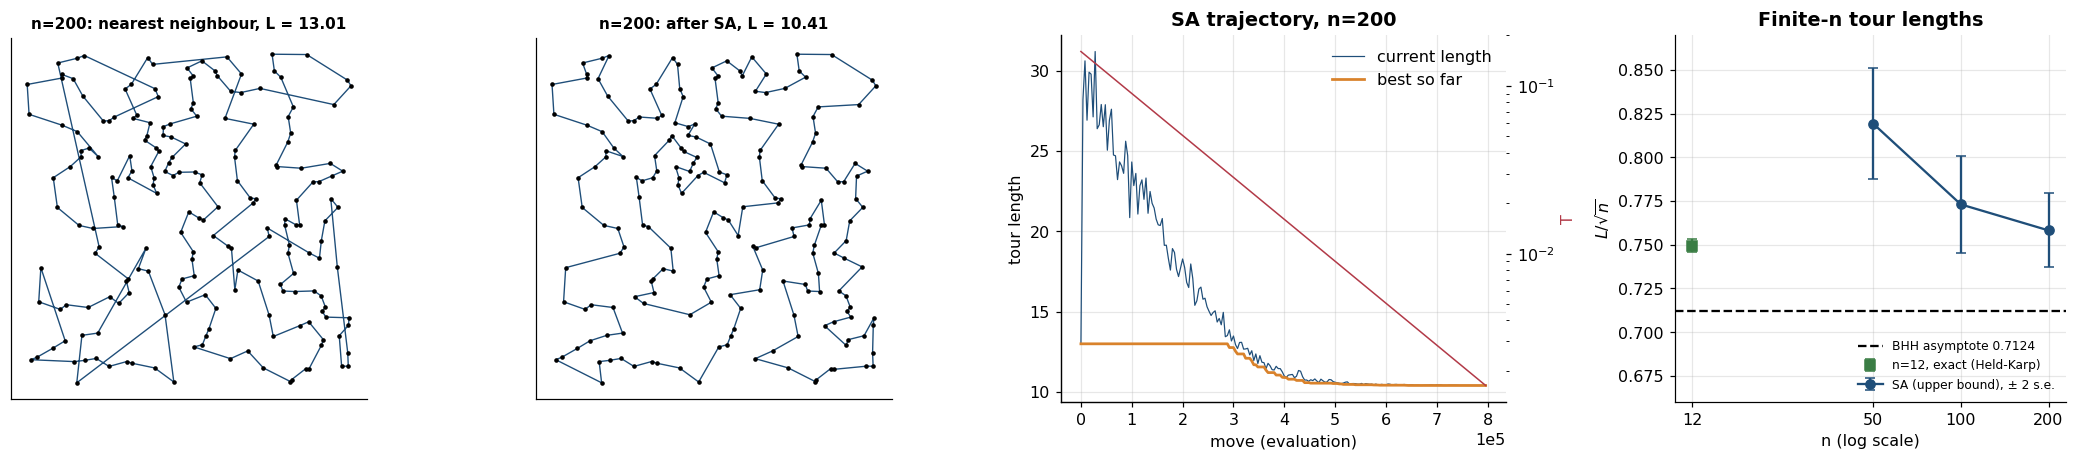

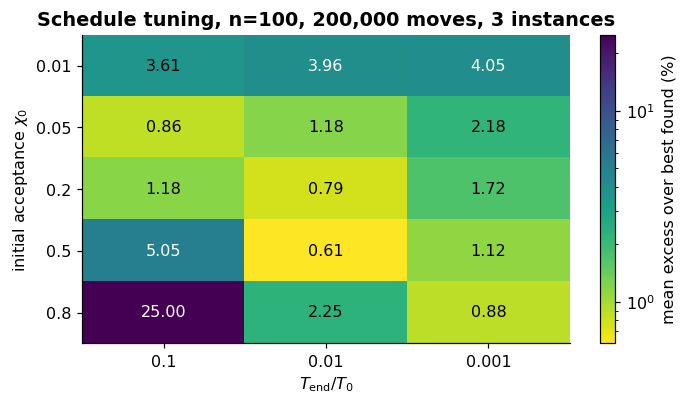

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(19, 4.3), gridspec_kw={"width_ratios": [1, 1, 1.25, 1.1]})
for a_, tour, ttl in [(ax[0], start, f"nearest neighbour, L = {L_start:.2f}"), (ax[1], bt, f"after SA, L = {L_best:.2f}")]:
    cyc = np.array(list(tour) + [tour[0]])
    a_.plot(pts[cyc, 0], pts[cyc, 1], "-", lw=0.9, c=PALETTE["blue"]); a_.plot(pts[:, 0], pts[:, 1], ".", c="k", ms=4)
    a_.set_aspect("equal"); a_.set_xticks([]); a_.set_yticks([]); a_.set_title(f"n=200: {ttl}", fontsize=10)
ax[2].plot(tr[:, 0], tr[:, 1], lw=0.8, label="current length")
ax[2].plot(tr[:, 0], tr[:, 2], lw=1.8, label="best so far")
ax2b = ax[2].twinx(); ax2b.semilogy(tr[:, 0], tr[:, 3], c=PALETTE["red"], lw=1); ax2b.set_ylabel("T", color=PALETTE["red"]); ax2b.grid(False)
ax[2].ticklabel_format(axis="x", style="sci", scilimits=(0, 0)); ax[2].set_xlabel("move (evaluation)"); ax[2].set_ylabel("tour length"); ax[2].set_title("SA trajectory, n=200"); ax[2].legend()
ax[3].errorbar([12], [bhh[12].mean()], yerr=[2 * bhh[12].std(ddof=1) / np.sqrt(len(bhh[12]))], fmt="s", capsize=3,
               c=PALETTE["green"], label="n=12, exact (Held-Karp)")
ax[3].errorbar(sizes, [bhh[n].mean() for n in sizes], yerr=[2 * bhh[n].std(ddof=1) / np.sqrt(len(bhh[n])) for n in sizes],
               fmt="o-", capsize=3, label="SA (upper bound), ± 2 s.e.")
ax[3].axhline(0.7124, ls="--", c="k", label="BHH asymptote 0.7124")
ax[3].set_xscale("log"); ax[3].minorticks_off(); ax[3].set_xticks([12] + sizes, [str(v) for v in [12] + sizes])
ax[3].set_xlabel("n (log scale)"); ax[3].set_ylabel(r"$L/\sqrt{n}$"); ax[3].set_title("Finite-n tour lengths")
ax[3].set_ylim(0.66, 0.87); ax[3].legend(fontsize=8, loc="lower right")
plt.tight_layout(); savefig("w2_tsp_tours.png"); plt.show()

fig, ax = plt.subplots(figsize=(6.5, 3.8))
from matplotlib.colors import LogNorm
norm = LogNorm(vmin=excess.min(), vmax=excess.max())       # 0.6% to 25%: a log colour scale keeps the small cells apart
im = ax.imshow(excess, cmap="viridis_r", aspect="auto", norm=norm)
ax.set_xticks(range(len(ends)), [f"{e:g}" for e in ends]); ax.set_yticks(range(len(chis)), [f"{c:g}" for c in chis])
ax.set_xlabel(r"$T_{\mathrm{end}}/T_0$"); ax.set_ylabel(r"initial acceptance $\chi_0$"); ax.grid(False)
for i_ in range(len(chis)):
    for j_ in range(len(ends)):
        ax.text(j_, i_, f"{excess[i_, j_]:.2f}", ha="center", va="center", color="w" if norm(excess[i_, j_]) > 0.5 else "k")
plt.colorbar(im, label="mean excess over best found (%)")
ax.set_title(f"Schedule tuning, n={n_st}, {K_st:,} moves, 3 instances")
plt.tight_layout(); savefig("w2_tsp_schedule_study.png"); plt.show()

**Reading Part A.** (i) The deltas are exact and the SA tours are provably optimal on every Held–Karp instance.
(ii) The tuning table shows the typical picture at a fixed budget: across reasonable cells the cost of a poor
schedule is 1–4% of tour length, and the best cell is printed above. The failure modes sit in the corners: a hot
start that never freezes ($\chi_0 = 0.8$ with $T_{\text{end}} = 0.1T_0$: +25%, SA ends as a random walk and destroys the
nearest-neighbour start) and a start that is too cold to escape the nearest-neighbour tour's structure
($\chi_0 = 0.01$: about +4% in every column). Hot starts need cold ends: along the anti-diagonal the results are
all good. Note what the winning cell does (trajectory panel): at $\chi_0=0.5$ the hot phase *destroys* the
nearest-neighbour tour — the current length more than doubles and the best-so-far stays at the start value for
roughly the first third of the budget. The good start is not preserved; its value is that $T_0$ is calibrated on
realistic deltas around a good tour instead of the huge deltas of a random one. (iii) The Held–Karp bound certifies
the SA tours: their optimality gap is at most the printed certified gap (median about 2%, part of which is the
bound's own slack of typically ~1%). A single SA run at this budget is therefore good but not optimal — the
$L/\sqrt n$ values above are upper bounds inflated by SA's own gap (most visibly at $n=50$, where one run is 4.9% above
the bound), while the lower-bound column decreases cleanly with $n$ (0.797, 0.758, 0.742). The bound also *proves*
that on every one of these instances $L^{\ast}_n/\sqrt n$ lies above the BHH constant 0.7124, as the boundary correction
in the unit square predicts. The exact $n=12$ value (two instances) lies *below* the $n=50$ one: tiny instances are
not in the asymptotic regime.

## Part B — MAX-3SAT near the phase transition

A random 3-SAT formula with $n$ variables and $m$ clauses is satisfiable with high probability for $m/n$ below
$\approx4.27$ and unsatisfiable above it (Mitchell, Selman & Levesque 1992; Kirkpatrick & Selman 1994; the precise
value $\alpha_s\approx4.267$ comes from the cavity method, Mézard, Parisi & Zecchina 2002). Instances near the
threshold are the hardest for complete and local solvers alike. We minimise the number of **unsatisfied clauses**.

**Incremental bookkeeping.** Keep, for every clause, the number of true literals `tc[c]`, and the set of
unsatisfied clauses in an array with O(1) insertion/removal. Flipping $x_v$ changes the number of unsatisfied clauses
by $\Delta = \text{break}(v) - \text{make}(v)$, where *break* counts clauses in which $x_v$ is the only true
literal and *make* counts unsatisfied clauses containing $x_v$ — both read from the $\approx 3m/n$ clauses that
contain $v$.

| Method | Proposal | Acceptance | Evaluations / step |
|---|---|---|---|
| **SA, focused** (Focused Metropolis Search; Seitz, Alava & Orponen 2005) | random variable of a random *unsatisfied* clause | Metropolis, geometric $T$ | 1 |
| **SA, unfocused** | uniformly random variable | Metropolis, geometric $T$ | 1 |
| **WalkSAT/SKC** (Selman, Kautz & Cohen 1994) | random unsatisfied clause; flip a variable with break $=0$ if any, else with prob. $p=0.5$ a random one of its 3 variables, else the one with least break | always flip | 3 |
| **Random-walk descent** | uniformly random variable | $\Delta\le0$ | 1 |

Budget: $3\times10^4$ evaluations; a run stops early if it satisfies the formula. SA: $T$ from $1.0$ to $0.05$
(untuned defaults).

In [9]:
class MaxSat:
    """Incremental MAX-SAT state: true-literal counts per clause and the set of unsatisfied clauses."""

    def __init__(self, clauses, n, assign):
        self.cl = [list(map(int, c)) for c in clauses]
        self.n = n
        self.a = [bool(x) for x in assign]
        self.occ = [[] for _ in range(n)]
        for ci, c in enumerate(self.cl):
            for lit in c:
                self.occ[abs(lit) - 1].append((ci, lit > 0))
        self.tc = [sum(self.a[abs(l) - 1] == (l > 0) for l in c) for c in self.cl]
        self.unsat, self.where = [], [-1] * len(self.cl)
        for ci, k in enumerate(self.tc):
            if k == 0:
                self._add(ci)

    def _add(self, ci):
        self.where[ci] = len(self.unsat); self.unsat.append(ci)

    def _remove(self, ci):
        k = self.where[ci]; last = self.unsat.pop()
        if last != ci:
            self.unsat[k] = last; self.where[last] = k
        self.where[ci] = -1

    def break_make(self, v):
        br = mk = 0; av = self.a[v]
        for ci, pos in self.occ[v]:
            k = self.tc[ci]
            if k == 0:
                mk += 1
            elif k == 1 and av == pos:
                br += 1
        return br, mk

    def flip(self, v):
        av = self.a[v]
        for ci, pos in self.occ[v]:
            if av == pos:                       # literal true before the flip
                self.tc[ci] -= 1
                if self.tc[ci] == 0: self._add(ci)
            else:
                self.tc[ci] += 1
                if self.tc[ci] == 1: self._remove(ci)
        self.a[v] = not av


def run_maxsat(clauses, n, method, budget, rng, T0=1.0, T_end=0.05, p_noise=0.5):
    st = MaxSat(clauses, n, rng.random(n) < 0.5)
    best = len(st.unsat); evals = 0
    alpha = (T_end / T0) ** (1 / budget); T = T0
    trace = [(0, best)]
    while evals < budget and st.unsat:
        if method in ("SA focused", "SA unfocused", "descent"):
            if method == "SA focused":
                c = st.cl[st.unsat[int(rng.integers(len(st.unsat)))]]
                v = abs(c[int(rng.integers(3))]) - 1
            else:
                v = int(rng.integers(n))
            br, mk = st.break_make(v); evals += 1
            d = br - mk
            if d <= 0 or (method != "descent" and rng.random() < math.exp(-d / T)):
                st.flip(v)
            T *= alpha
        else:  # WalkSAT / SKC
            c = st.cl[st.unsat[int(rng.integers(len(st.unsat)))]]
            vs = [abs(l) - 1 for l in c]
            brs = [st.break_make(v)[0] for v in vs]; evals += 3
            if min(brs) == 0:
                v = vs[brs.index(0)]
            elif rng.random() < p_noise:
                v = vs[int(rng.integers(3))]
            else:
                v = vs[int(np.argmin(brs))]
            st.flip(v)
        if len(st.unsat) < best:
            best = len(st.unsat); trace.append((evals, best))
    trace.append((evals, best))
    return best, st, np.array(trace)


# --- validation 1: bookkeeping against utils.count_satisfied after many random flips
clauses = random_max3sat(50, 213, np.random.default_rng(4))
st = MaxSat(clauses, 50, np.random.default_rng(5).random(50) < 0.5)
vr = np.random.default_rng(6); ok = True
for _ in range(2000):
    v = int(vr.integers(50)); br, mk = st.break_make(v); before = len(st.unsat)
    st.flip(v)
    ok &= (len(st.unsat) - before == br - mk)
check_true(ok, "predicted delta (break - make) equals the actual change for 2000 random flips")
check_close(len(clauses) - len(st.unsat), count_satisfied(np.array(st.a), clauses),
            "incremental satisfied count = utils.count_satisfied")

[PASS] predicted delta (break - make) equals the actual change for 2000 random flips
[PASS] incremental satisfied count = utils.count_satisfied: got 186, expected 186


In [10]:
# --- validation 2: exact optimum by exhaustive enumeration of 2^20 assignments
n_small, m_small = 20, 110                     # m/n = 5.5: almost surely unsatisfiable, so the optimum is > 0
cl_small = random_max3sat(n_small, m_small, np.random.default_rng(7))
codes = np.arange(2**n_small, dtype=np.int64)
n_sat = np.zeros(2**n_small, dtype=np.int16)
for c in cl_small:
    sat = np.zeros(2**n_small, dtype=bool)
    for lit in c:
        bit = ((codes >> (abs(lit) - 1)) & 1).astype(bool)
        sat |= bit if lit > 0 else ~bit
    n_sat += sat
best_exact = m_small - int(n_sat.max())
k_arg = int(np.argmax(n_sat))
check_close(count_satisfied(np.array([(k_arg >> i) & 1 for i in range(n_small)], dtype=bool), cl_small),
            int(n_sat.max()), "enumeration agrees with utils.count_satisfied at its argmax")
res_small = [run_maxsat(cl_small, n_small, "SA focused", 20000, np.random.default_rng(s))[0] for s in range(10)]
print(f"n={n_small}, m={m_small}: exact minimum #unsat = {best_exact}; SA-focused over 10 seeds: {res_small}")
check_true(all(r == best_exact for r in res_small), "SA (focused) attains the exact MAX-SAT optimum in all 10 runs")

[PASS] enumeration agrees with utils.count_satisfied at its argmax: got 108, expected 108


n=20, m=110: exact minimum #unsat = 2; SA-focused over 10 seeds: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
[PASS] SA (focused) attains the exact MAX-SAT optimum in all 10 runs


In [11]:
n_var, ratio = 200, 4.26
m_cl = int(round(ratio * n_var))
sat_methods = ["SA focused", "SA unfocused", "WalkSAT (SKC)", "descent"]
n_inst_sat, B_sat = 20, 30000
sat_res = {m: np.zeros(n_inst_sat, dtype=int) for m in sat_methods}
sat_evals = {m: np.zeros(n_inst_sat) for m in sat_methods}
sat_traces = {}
for a in range(n_inst_sat):
    cl = random_max3sat(n_var, m_cl, np.random.default_rng(500 + a))
    for m in sat_methods:
        b, _, tr = run_maxsat(cl, n_var, m, B_sat, np.random.default_rng(900 + a))
        sat_res[m][a], sat_evals[m][a] = b, tr[-1, 0]
        if a == 0:
            sat_traces[m] = tr
print(f"random 3-SAT, n={n_var}, m={m_cl} (m/n={ratio}), {n_inst_sat} instances, budget {B_sat} evaluations")
for m in sat_methods:
    solved = sat_res[m] == 0
    ev = f"median evals when solved {np.median(sat_evals[m][solved]):.0f}" if solved.any() else ""
    print(f"  {m:14s} unsat clauses: median {np.median(sat_res[m]):.1f}, max {sat_res[m].max()}, "
          f"solved {solved.sum()}/{n_inst_sat}  {ev}")
pairs_sat = [("SA focused", "SA unfocused"), ("SA focused", "descent"), ("SA unfocused", "descent"),
             ("WalkSAT (SKC)", "descent"), ("WalkSAT (SKC)", "SA focused")]
for m1, m2 in pairs_sat:   # paired by instance; zsplit handles the many ties at zero difference
    print(f"Wilcoxon (paired by instance) {m1} vs {m2}: p = "
          f"{wilcoxon(sat_res[m1], sat_res[m2], zero_method='zsplit').pvalue:.2g}")

random 3-SAT, n=200, m=852 (m/n=4.26), 20 instances, budget 30000 evaluations
  SA focused     unsat clauses: median 1.0, max 4, solved 2/20  median evals when solved 1662
  SA unfocused   unsat clauses: median 2.0, max 5, solved 1/20  median evals when solved 19038
  WalkSAT (SKC)  unsat clauses: median 1.0, max 2, solved 7/20  median evals when solved 8685
  descent        unsat clauses: median 3.0, max 6, solved 2/20  median evals when solved 16611
Wilcoxon (paired by instance) SA focused vs SA unfocused: p = 0.024
Wilcoxon (paired by instance) SA focused vs descent: p = 0.0036
Wilcoxon (paired by instance) SA unfocused vs descent: p = 0.025
Wilcoxon (paired by instance) WalkSAT (SKC) vs descent: p = 0.00023
Wilcoxon (paired by instance) WalkSAT (SKC) vs SA focused: p = 0.019


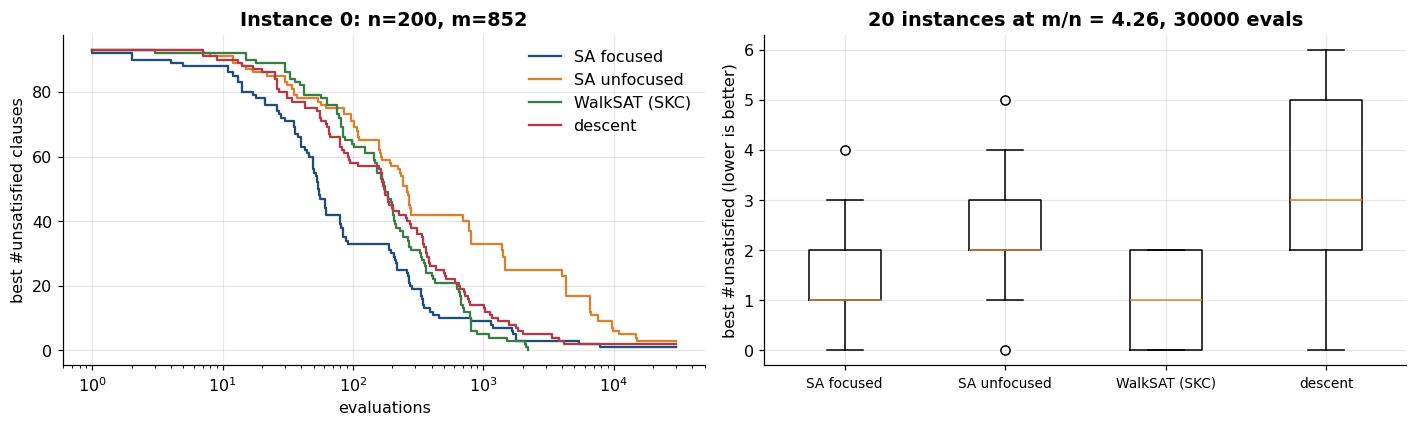

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for m in sat_methods:
    tr = sat_traces[m]
    ax[0].step(np.maximum(tr[:, 0], 1), tr[:, 1], where="post", label=m)
ax[0].set_xscale("log"); ax[0].set_xlabel("evaluations"); ax[0].set_ylabel("best #unsatisfied clauses")
ax[0].set_title(f"Instance 0: n={n_var}, m={m_cl}"); ax[0].legend()
ax[1].boxplot([sat_res[m] for m in sat_methods]); ax[1].set_xticks(range(1, 5), sat_methods, fontsize=9)
ax[1].set_ylabel("best #unsatisfied (lower is better)"); ax[1].set_title(f"{n_inst_sat} instances at m/n = {ratio}, {B_sat} evals")
plt.tight_layout(); savefig("w2_maxsat.png"); plt.show()

**Reading Part B.** *Focusing* — proposing only variables that occur in unsatisfied clauses — is the mechanism that
matters most: every focused proposal can repair something, whereas a uniformly random variable is usually
irrelevant. With the same (untuned) schedule, focused SA beats unfocused SA (median 1 vs 2 unsatisfied clauses,
paired Wilcoxon $p\approx0.02$), and all three stochastic methods beat plain descent (paired $p\le 0.025$, printed
above; $p = 0.004$ for focused SA). WalkSAT, which shares the
focusing and replaces the Metropolis coin by break-count greed plus noise, is the strongest here (most formulas
satisfied of all methods, 7 of 20, and never more than 2 clauses unsatisfied; $p\approx 0.02$ against focused SA) — even though it is charged
3 evaluations per step. (Five tests on 20 instances: only WalkSAT vs descent and focused SA vs descent survive a
Holm correction for multiple testing — treat the other differences, including focused vs unfocused, as indicative.) At
$m/n = 4.26$ a sizeable fraction of random formulas is unsatisfiable, so "unsolved" does not mean "failed":
certifying that 1 unsatisfied clause is optimal requires a complete (e.g. DPLL/CDCL-based MaxSAT) solver.

## Part C — SA for hyperparameter and feature-subset search (AI link)

Discrete configuration spaces — which features, which regularisation strength, which layer type — are exactly the
spaces where local moves + Metropolis acceptance apply. We take a small ridge-regression problem with $p=12$
candidate features (4 informative, 4 noisy copies of informative ones, 4 pure noise) and a grid of 5
regularisation strengths: $2^{12}\cdot 5 = 20\,480$ configurations, few enough to **enumerate exactly**. The
objective is validation MSE; each evaluation fits a ridge model. SA moves flip one feature bit (prob. 0.8) or shift
$\lambda$ one grid step. We compare SA, random search and random-walk descent at **150 evaluations** (0.7% of the
space), 30 seeds.

In [13]:
dr = np.random.default_rng(12)
n_tr, n_va, p_f = 60, 200, 12
Z = dr.standard_normal((n_tr + n_va, 4))
Xf = np.hstack([Z, Z + 0.8 * dr.standard_normal(Z.shape), dr.standard_normal((n_tr + n_va, 4))])
yf = Z @ np.array([1.0, -0.8, 0.6, 0.4]) + 0.8 * dr.standard_normal(n_tr + n_va)
Xtr, Xva, ytr, yva = Xf[:n_tr], Xf[n_tr:], yf[:n_tr], yf[n_tr:]
lambdas = np.array([1e-3, 1e-2, 1e-1, 1.0, 10.0])


def val_mse(mask, li):
    idx = np.flatnonzero(mask)
    if idx.size == 0:
        return float(np.mean((yva - ytr.mean()) ** 2))
    A, mu, ym = Xtr[:, idx], Xtr[:, idx].mean(0), ytr.mean()
    Ac = A - mu
    w = np.linalg.solve(Ac.T @ Ac + lambdas[li] * np.eye(idx.size), Ac.T @ (ytr - ym))
    return float(np.mean((yva - ym - (Xva[:, idx] - mu) @ w) ** 2))


masks = ((np.arange(2**p_f)[:, None] >> np.arange(p_f)) & 1).astype(bool)
table = np.array([[val_mse(mk, li) for li in range(len(lambdas))] for mk in masks])
opt_val = table.min()
o_mask, o_li = np.unravel_index(np.argmin(table), table.shape)
print(f"exhaustive optimum: val MSE {opt_val:.4f}, features {np.flatnonzero(masks[o_mask]).tolist()}, lambda {lambdas[o_li]}")
# independent check of the ridge solver at one configuration against numpy least squares on an augmented system
mk, li = masks[o_mask], o_li
idx = np.flatnonzero(mk); Ac = Xtr[:, idx] - Xtr[:, idx].mean(0)
Aaug = np.vstack([Ac, np.sqrt(lambdas[li]) * np.eye(idx.size)])
w_ls = np.linalg.lstsq(Aaug, np.concatenate([ytr - ytr.mean(), np.zeros(idx.size)]), rcond=None)[0]
pred = ytr.mean() + (Xva[:, idx] - Xtr[:, idx].mean(0)) @ w_ls
check_close(np.mean((yva - pred) ** 2), opt_val, "ridge via normal equations = augmented least squares", atol=1e-10)


def hpo_search(method, budget, rng, T0=0.02, T_end=2e-4):
    code = lambda m, l: (int(np.dot(m, 1 << np.arange(p_f))), l)
    if method == "random search":
        vals = [table[rng.integers(2**p_f), rng.integers(5)] for _ in range(budget)]
        return min(vals)
    m = rng.random(p_f) < 0.5; l = int(rng.integers(5))
    f = table[code(m, l)]; best = f
    alpha = (T_end / T0) ** (1 / budget); T = T0
    for _ in range(budget - 1):
        m2, l2 = m.copy(), l
        if rng.random() < 0.8:
            j = rng.integers(p_f); m2[j] = ~m2[j]
        else:
            l2 = int(np.clip(l + rng.choice([-1, 1]), 0, 4))
        f2 = table[code(m2, l2)]                       # one "training run" (looked up from the exact table)
        if f2 <= f or (method == "SA" and rng.random() < np.exp(-(f2 - f) / T)):
            m, l, f = m2, l2, f2
        best = min(best, f); T *= alpha
    return best


hpo = {meth: np.array([hpo_search(meth, 150, np.random.default_rng(s)) - opt_val for s in range(30)])
       for meth in ["SA", "descent", "random search"]}
for meth, r in hpo.items():
    print(f"{meth:14s} regret median {np.median(r):.4f} IQR [{np.percentile(r, 25):.4f}, {np.percentile(r, 75):.4f}]"
          f"  exact optimum found in {np.mean(r < 1e-12):.0%} of runs")
# SA and descent with the same seed start from the same configuration -> paired binary outcomes: exact McNemar test
sa_ok, de_ok = hpo["SA"] < 1e-12, hpo["descent"] < 1e-12
n10, n01 = int(np.sum(sa_ok & ~de_ok)), int(np.sum(~sa_ok & de_ok))
print(f"SA vs descent, paired success: SA-only {n10}, descent-only {n01}; exact McNemar p = "
      f"{binomtest(n10, n10 + n01, 0.5).pvalue if n10 + n01 else 1.0:.2g}")

exhaustive optimum: val MSE 0.5775, features [0, 1, 2, 3, 6], lambda 1.0
[PASS] ridge via normal equations = augmented least squares: got 0.577507, expected 0.577507


SA             regret median 0.0000 IQR [0.0000, 0.0000]  exact optimum found in 77% of runs
descent        regret median 0.0000 IQR [0.0000, 0.0045]  exact optimum found in 67% of runs
random search  regret median 0.0177 IQR [0.0132, 0.0269]  exact optimum found in 3% of runs
SA vs descent, paired success: SA-only 7, descent-only 4; exact McNemar p = 0.55


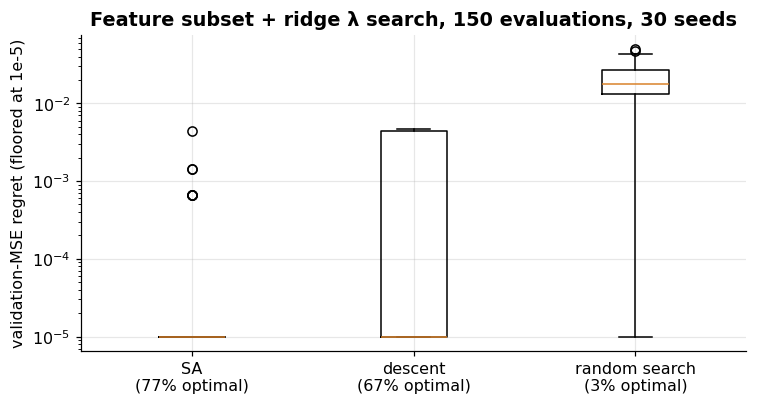

In [14]:
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.boxplot([np.maximum(hpo[m], 1e-5) for m in hpo]); ax.set_yscale("log")
ax.set_xticks(range(1, 4), [f"{m}\n({np.mean(hpo[m] < 1e-12):.0%} optimal)" for m in hpo])
ax.set_ylabel("validation-MSE regret (floored at 1e-5)")
ax.set_title("Feature subset + ridge λ search, 150 evaluations, 30 seeds")
plt.tight_layout(); savefig("w2_hpo_search.png"); plt.show()

**Reading Part C.** On a problem whose exact optimum we know, both local methods crush random search (which samples
0.7% of the space blindly). SA's controlled uphill moves give a small further edge over pure descent in success rate
and upper-quartile regret, but with 30 paired seeds this edge is **not statistically significant** (exact McNemar
test above) — a typical outcome on a small, benign landscape. Structure helps because neighbouring configurations have similar
losses (adding or dropping one feature changes the validation error smoothly); uphill moves let SA leave a feature
set that is locally optimal under single flips — e.g. one that contains a noisy copy instead of the informative
original. In real
hyperparameter optimisation each evaluation is a training run, the landscape is noisy (the validation loss is a
random variable), and SA competes with Bayesian optimisation and bandit methods (Hyperband); its appeal is
simplicity and natural handling of discrete/conditional choices, as in early neural-architecture-search baselines.

## Key takeaways

- A competitive SA for the TSP is mostly engineering: $O(1)$ deltas (validated against full recomputation),
  neighbour lists, a good start tour and a schedule calibrated from acceptance ratios; it provably found every
  Held–Karp optimum for $n\le12$.
- At a fixed budget the schedule parameters ($\chi_0$, $T_{\text{end}}/T_0$) change tour quality by a few percent;
  tune them on pilot instances with common random numbers.
- A Held–Karp 1-tree bound turns SA's upper bounds into **certified** gaps (about 2% here) and proves that finite-$n$
  optimal tours in the unit square lie above the BHH asymptote $0.7124\sqrt{n}$.
- For MAX-3SAT near the threshold, **focusing** proposals on unsatisfied clauses is the mechanism that matters most:
  the two focused methods are the ones whose advantage over descent survives a multiple-testing correction. The
  exact optimum was reproduced on an exhaustively solved instance.
- Report paired tests (and multiplicity corrections) for every claimed difference; small advantages, such as SA
  over descent in Part C, often turn out not to be significant.
- The same SA loop handles discrete hyperparameter/feature-subset search, where it can be validated exactly on
  small spaces before it is trusted on expensive ones.

## Exercises

1. ★ Prove that a 2-opt move and its inverse have opposite deltas, and that the 2-opt neighbourhood of a tour on
   $n$ cities has exactly $n(n-3)/2$ distinct non-trivial moves.
2. ★ Add the **3-opt "segment insertion"** special case with $L$ up to $n/2$ (not just 3) and measure whether the
   or-opt share $p_{\text{or}}$ should change with $n$.
3. ★★ Replace the geometric schedule by the adaptive modified-Lam schedule of Notebook 2 and repeat the tuning study:
   does adaptation remove the sensitivity to $\chi_0$?
4. ★★ Implement **Lin–Kernighan-style don't-look bits** (Bentley 1992) in the SA: skip cities whose neighbourhood
   produced no accepted move in the last sweep. Measure the speed-up per evaluation and its effect on quality.
5. ★★ For focused SA on 3-SAT, scan the temperature at a *fixed* $T$ (no annealing) and plot the median time to
   solution against $\eta = e^{-1/T}$ for $m/n\in\lbrace 3.8, 4.0, 4.2\rbrace$; compare with the optimal $\eta$ reported
   by Seitz, Alava & Orponen (2005).
6. ★★★ Make Part C noisy: each evaluation returns the validation MSE on a random half of the validation set.
   Show that plain SA then over-accepts lucky evaluations, and implement and test a remedy (re-evaluation of the
   incumbent, or averaging over $r$ evaluations at an equal total budget).